# 01 · Exploratory Data Analysis
**Airline Sentiment Intelligence** — Twitter US Airline Sentiment dataset

This notebook explores the *raw* dataset before any cleaning, to understand class balance, text length, missingness, and per-airline patterns. All reusable logic (loading, validation) is imported from `src/`, not reimplemented here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import RAW_DATASET_PATH, LABEL_COLUMN, TEXT_COLUMN, CLASS_NAMES
from src.data.validation import validate_raw_dataframe

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 110

## Load & validate

In [2]:
df = pd.read_csv(RAW_DATASET_PATH)
validate_raw_dataframe(df)
print(f'{len(df):,} rows, {df.shape[1]} columns')
df.head(3)

2026-09-12 01:00:41,909 | INFO     | src.data.validation | Validation passed: 14640 rows, 15 columns, 3 unique labels.


14,640 rows, 15 columns


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


## Missingness

In [3]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0].round(1)

negativereason_gold          99.8
airline_sentiment_gold       99.7
tweet_coord                  93.0
negativereason               37.3
user_timezone                32.9
tweet_location               32.3
negativereason_confidence    28.1
dtype: float64

`negativereason` is only populated for negative tweets by construction — everything else is either fully populated or (`tweet_coord`, `airline_sentiment_gold`) sparsely populated fields we don't need.

## Class balance

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

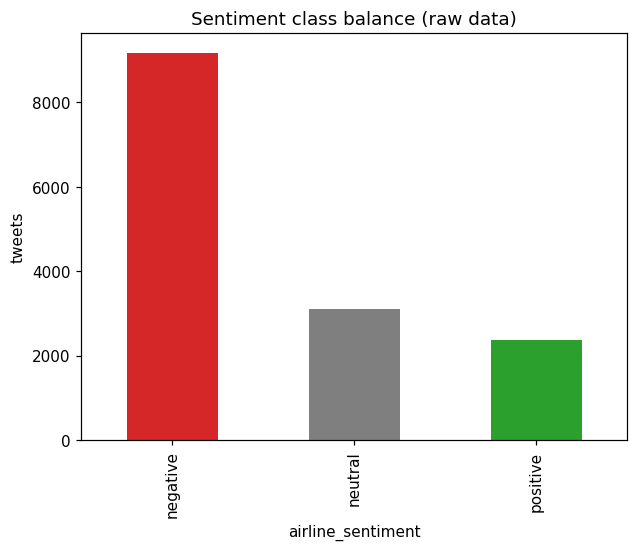

In [4]:
counts = df[LABEL_COLUMN].value_counts()
display(counts)
ax = counts.reindex(CLASS_NAMES).plot(kind='bar', color=['#d62728','#7f7f7f','#2ca02c'])
ax.set_title('Sentiment class balance (raw data)')
ax.set_ylabel('tweets')
plt.show()

**Observation:** the dataset is heavily skewed toward negative tweets (~63%), which matches real-world airline social-media mentions — people are far more likely to tweet a complaint than praise. This imbalance is handled later via class weighting during training (see `src/training/train_lstm.py`), and macro-averaged metrics (not just accuracy) are used throughout evaluation so the minority `neutral`/`positive` classes aren't invisible in the results.

## Sentiment by airline

In [5]:
by_airline = pd.crosstab(df['airline'], df[LABEL_COLUMN], normalize='index')[CLASS_NAMES]
by_airline.sort_values('negative', ascending=False).round(2)

airline_sentiment,negative,neutral,positive
airline,,,
US Airways,0.78,0.13,0.09
American,0.71,0.17,0.12
United,0.69,0.18,0.13
Southwest,0.49,0.27,0.24
Delta,0.43,0.33,0.24
Virgin America,0.36,0.34,0.30


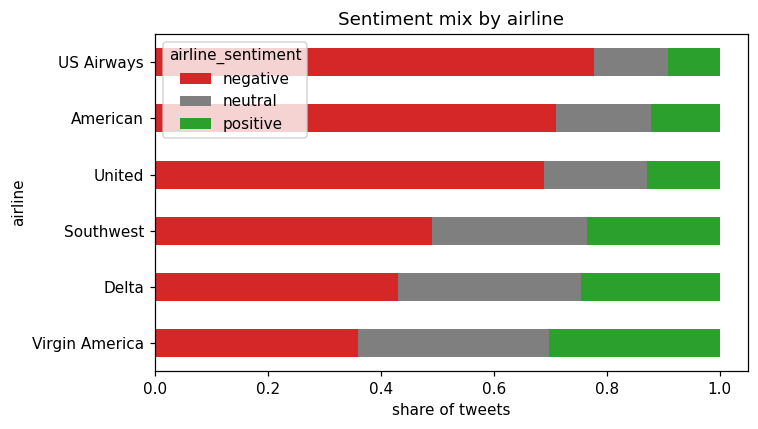

In [6]:
ax = by_airline.sort_values('negative').plot(kind='barh', stacked=True,
    color=['#d62728','#7f7f7f','#2ca02c'], figsize=(7,4))
ax.set_title('Sentiment mix by airline')
ax.set_xlabel('share of tweets')
plt.tight_layout(); plt.show()

## Top reasons behind negative tweets

In [7]:
df['negativereason'].value_counts().head(10)

negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64

Late flights, poor customer service, and lost baggage dominate — this is useful business context even beyond the 3-way sentiment label, and is surfaced in the Streamlit app's Dataset Explorer page.

## Tweet length

count    14640.000000
mean        17.653415
std          6.882259
min          2.000000
25%         12.000000
50%         19.000000
75%         23.000000
max         36.000000
Name: text, dtype: float64


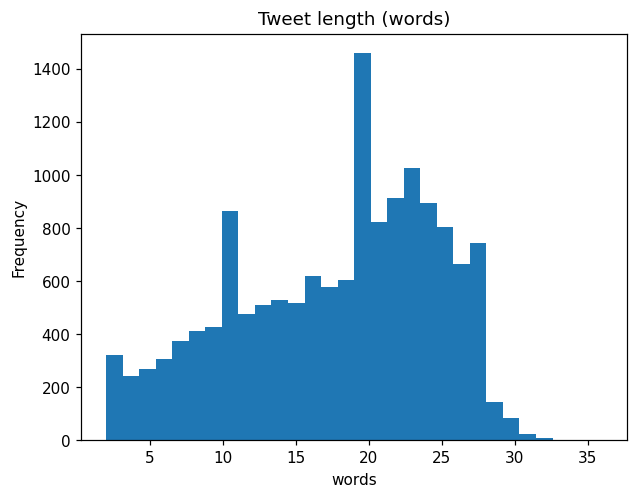

In [8]:
lengths = df[TEXT_COLUMN].str.split().apply(len)
print(lengths.describe())
lengths.plot(kind='hist', bins=30, title='Tweet length (words)')
plt.xlabel('words'); plt.show()

Tweets are short (median ~15-17 words, capped historically at 140 characters), which directly informed the `max_sequence_length=40` choice in `src/config.py` — long enough to cover almost every tweet without wasting compute on padding.

## Takeaways feeding into preprocessing (`src/data/preprocessing.py`)
- Strong class imbalance → use class weighting + macro F1, not raw accuracy alone.
- `@mentions` are almost always the airline handle → stripped, to stop the model from learning "which airline" as a shortcut for sentiment.
- Tweets are short → 40-token sequence length is generous, not limiting.
- A small number of exact duplicate tweets (retweets/bot spam) exist → deduplicated during cleaning to avoid leaking near-identical examples across train/val/test.